In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [14]:
np.random.seed(42)
x,y=make_circles(n_samples=500,factor=0.1,noise=0.35,random_state=42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,)

In [15]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((400, 2), (400,), (100, 2), (100,))

In [16]:
x.shape,y.shape

((500, 2), (500,))

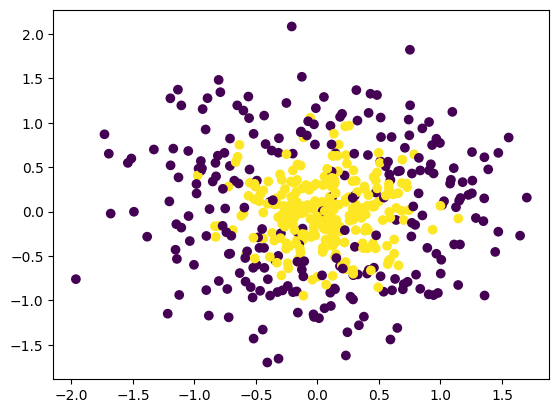

In [17]:
plt.scatter(x[:,0],x[:,1],c=y)

In [18]:
from sklearn.tree import DecisionTreeClassifier

xx1.ravel(), xx2.ravel(): Flattens the meshgrid into a 1D array.
np.c_[xx1.ravel(), xx2.ravel()]: Combines the two flattened arrays column-wise to form a 2D array (input features).
dtree.predict(...): Uses the trained Decision Tree model to predict labels for the entire grid.
y_hat.reshape(xx1.shape): Reshapes the flat predictions back to the shape of xx1, so it can be used for contour plotting.

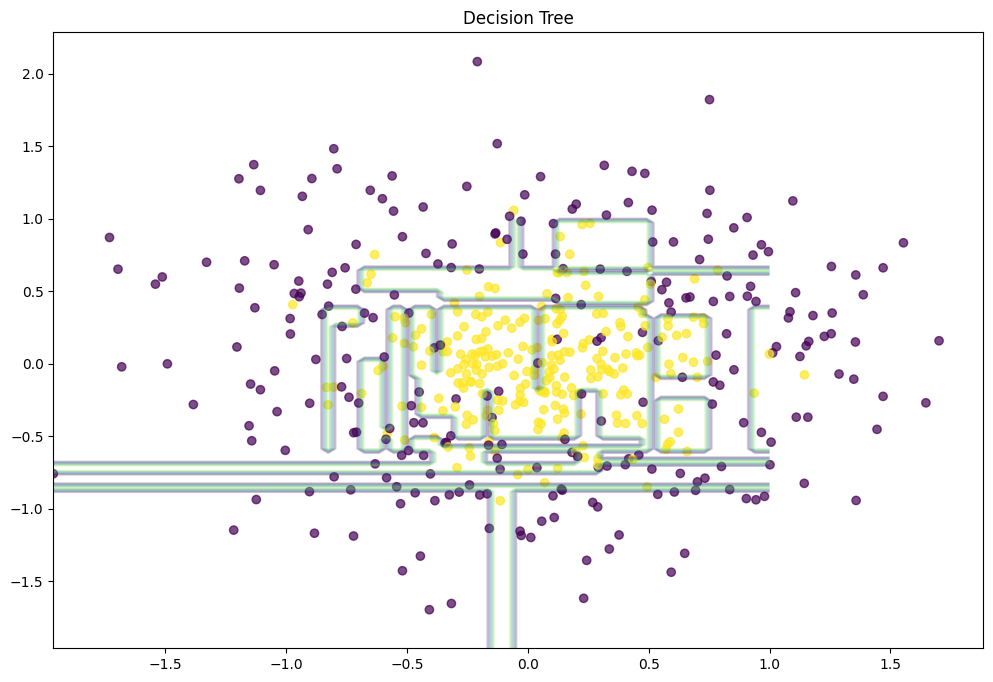

In [23]:
dtree=DecisionTreeClassifier(random_state=42)
dtree.fit(x_train,y_train)

plt.figure(figsize=(12,8))
x_range=np.linspace(x.min(),y.max(),100)
xx1,xx2=np.meshgrid(x_range,x_range)
y_hat=dtree.predict(np.c_[xx1.ravel(),xx2.ravel()])
y_hat=y_hat.reshape(xx1.shape)
plt.contour(xx1,xx2,y_hat,alpha=0.2)
plt.scatter(x[:,0],x[:,1],c=y,cmap='viridis',alpha=0.7)
plt.title("Decision Tree")
plt.show()

In [29]:
xx1.shape

(100, 100)

In [30]:
y_hat.shape

(100, 100)

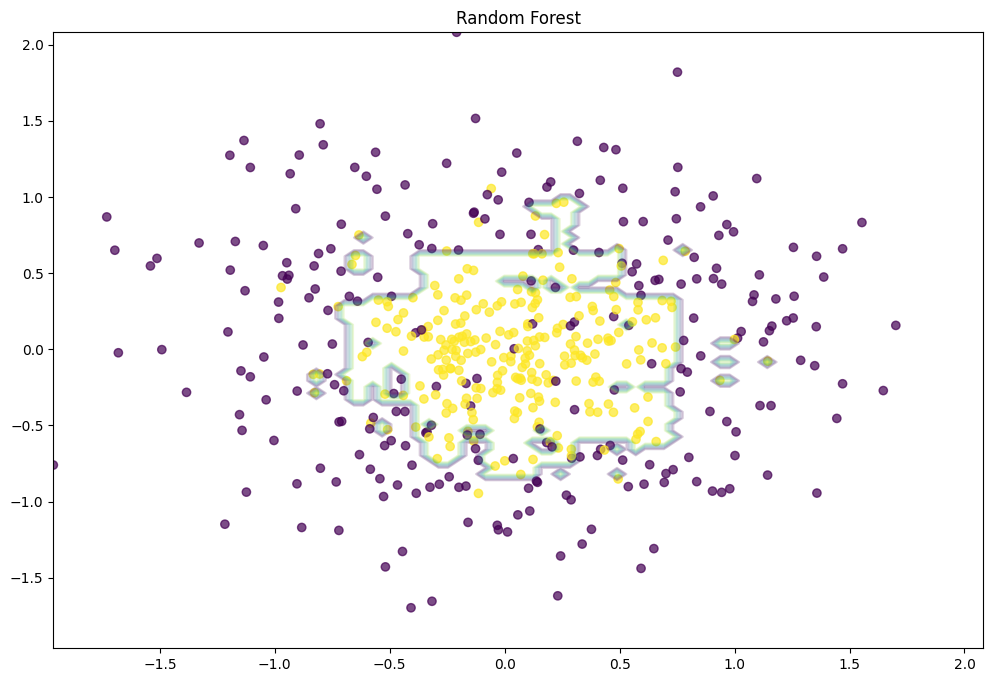

In [34]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=500,random_state=42)
rf.fit(x_train,y_train)

plt.figure(figsize=(12,8))
x_range=np.linspace(x.min(),x.max(),100)
xx1,xx2=np.meshgrid(x_range,x_range)
y_hat=rf.predict(np.c_[xx1.ravel(),xx2.ravel()])
y_hat=y_hat.reshape(xx1.shape)
plt.contour(xx1,xx2,y_hat,alpha=0.2)
plt.scatter(x[:,0],x[:,1],c=y,cmap='viridis',alpha=0.7)
plt.title("Random Forest")
plt.show()

In [51]:
n_train=150
n_test=1000
noise=0.1

def f(x):
    x=x.ravel()
    return np.exp(-x**2)+1.5* np.exp(-(x-2)**2)

def generate(n_samples,noise):
    x=np.random.rand(n_samples)*10 -5
    x=np.sort(x).ravel()
    y=np.exp(-x**2)+1.5* np.exp(-(x-2)**2)+np.random.normal(0.0,noise,n_samples)
    x=x.reshape(n_samples,1)
    
    return x,y

In [52]:
x_train,y_train=generate(n_samples=n_train,noise=noise)
x_test,y_test=generate(n_samples=n_test,noise=noise)

(-5.0, 5.0)

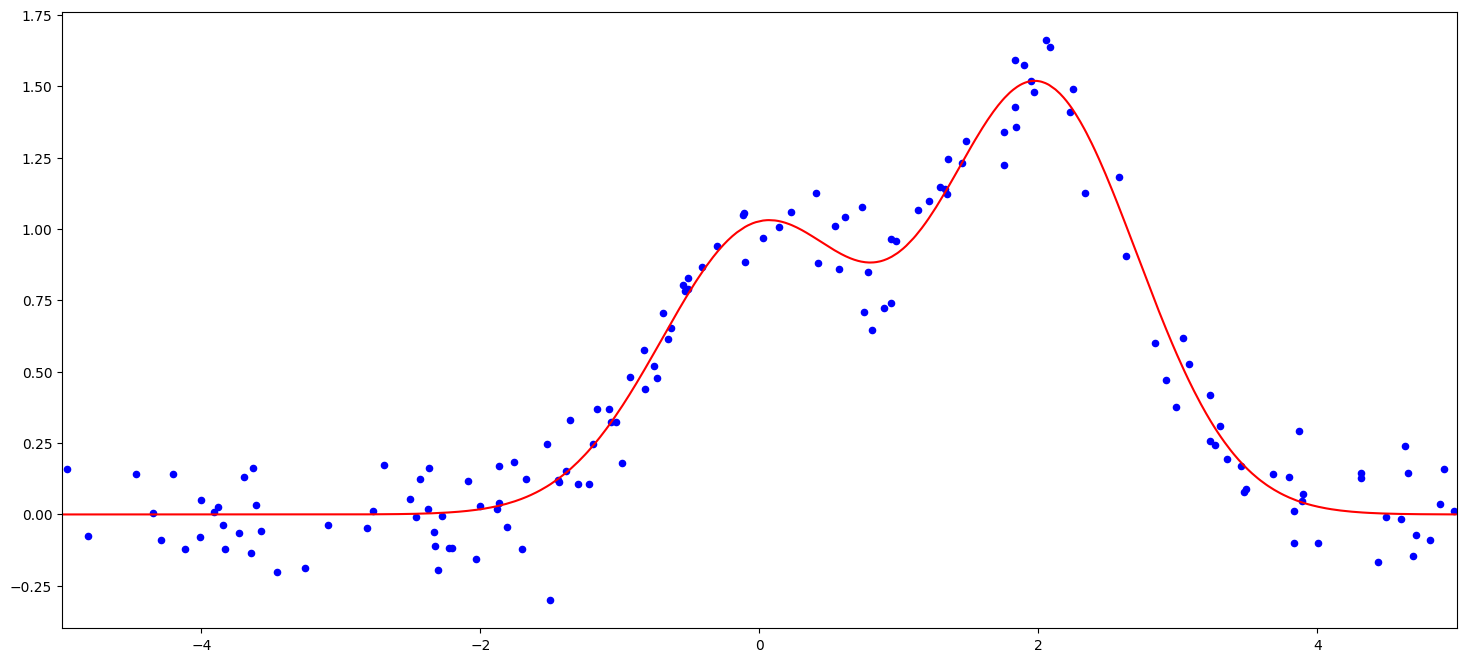

In [53]:
plt.figure(figsize=(18,8))
plt.plot(x_test,f(x_test),'r')
plt.scatter(x_train,y_train,c='b',s=20)
plt.xlim([-5,5])

Text(0.5, 1.0, 'Decision tree,MSE:23.01')

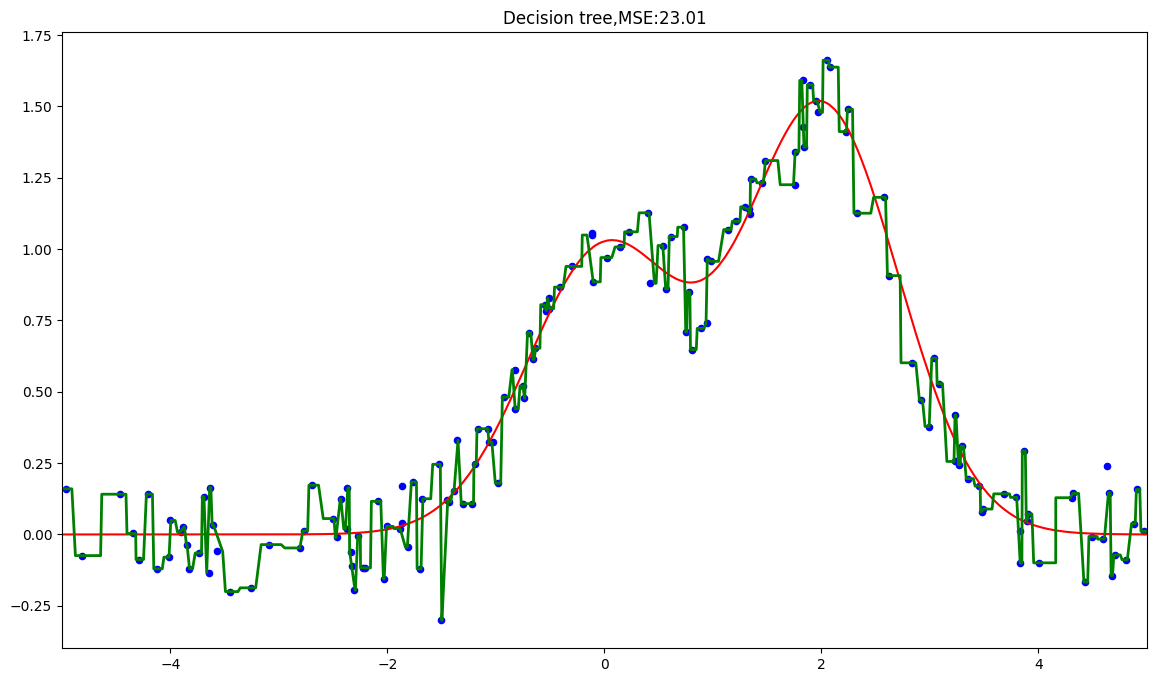

In [54]:
#one decision tree regressor
from sklearn.tree import DecisionTreeRegressor

dtree=DecisionTreeRegressor().fit(x_train,y_train)
d_predict=dtree.predict(x_test)
plt.figure(figsize=(14,8))
plt.plot(x_test,f(x_test),'r')
plt.scatter(x_train,y_train,c='b',s=20)
plt.plot(x_test,d_predict,'g',lw=2)
plt.xlim([-5,5])
plt.title("Decision tree,MSE:%.2f"%np.sum((y_test - d_predict)**2))

Text(0.5, 1.0, 'Decision tree,MSE:23.01')

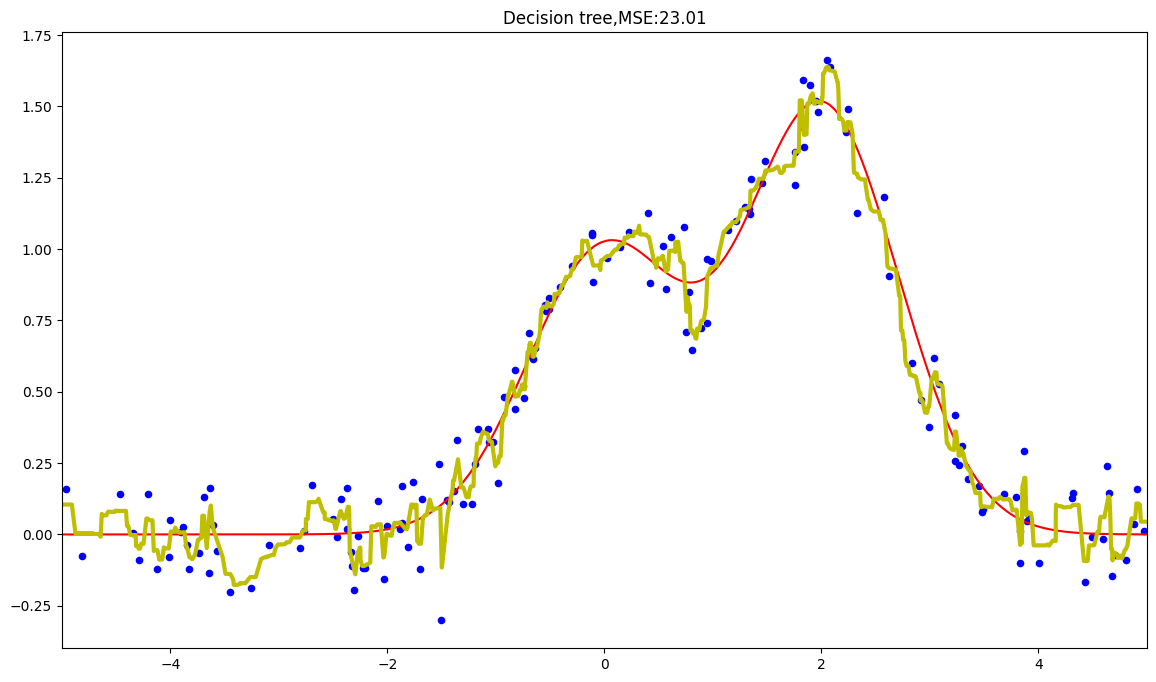

In [60]:
#one Random Forest 
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
rfg=RandomForestRegressor(n_estimators=500).fit(x_train,y_train)
rfg_predict=rfg.predict(x_test)
dtree=DecisionTreeRegressor().fit(x_train,y_train)
d_predict=dtree.predict(x_test)
plt.figure(figsize=(14,8))
plt.plot(x_test,f(x_test),'r')
plt.scatter(x_train,y_train,c='b',s=20)
#plt.plot(x_test,d_predict,'g',lw=2)
plt.plot(x_test,rfg_predict,'y',lw=3)
plt.xlim([-5,5])
plt.title("Decision tree,MSE:%.2f"%np.sum((y_test - d_predict)**2))